This notebook is part the of Dr. Christoforos Christoforou's course materials. You may not, nor may you knowingly allow others to reproduce or distribute lecture notes, course materials or any of their derivatives without the instructor's express written consent.

# Problem Set 02 - Instance-based Classifiers
**Professor:** Dr. Christoforos Christoforou

For this problem set you will need the following libraries, which are pre-installed with the colab environment:

* [Numpy](https://www.numpy.org/) is an array manipulation library, used for linear algebra, Fourier transform, and random number capabilities.
* [Pandas](https://pandas.pydata.org/) is a library for data manipulation and data analysis.
* [Matplotlib](https://matplotlib.org/) is a library which generates figures and provides graphical user interface toolkit.

You can load them using the following import statement:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt

## 1. Objective
As part of this problem set, you will expore work on the `wine quality dataset`  in order to:
- To explore the physiocochemical properties of red wine
- To determine an optimal machine learning model for red wine quality classification

For that, you will be using an `instance-based` classifier, namely K-NN algorithm. Review the information provided in the problem set, and complete all challenges listed.  

## 2. Wine Quality Dataset - Data Description

For this dataset you will be using the `wine quality dataset`. Below is a description of the various parameters listed in that dataset (i.e. potential features):

* fixed.acidity (tartaric acid - g / dm^3): most acids involved with wine or fixed or nonvolatile (do not evaporate readily)
* volatile.acidity (acetic acid - g / dm^3): the amount of acetic acid in wine, which at too high of levels can lead to an unpleasant, vinegar taste
* citric.acid (g / dm^3): the amount of acetic acid in wine, which at too high of levels can lead to an unpleasant, vinegar taste
* residual.sugar (g / dm^3): the amount of sugar remaining after fermentation stops, it's rare to find wines with less than 1 gram/liter and wines with greater than 45 grams/liter are considered sweet
* chlorides (sodium chloride - g / dm^3): the amount of salt in the wine
* free.sulfur.dioxide (mg / dm^3): the free form of SO2 exists in equilibrium between molecular SO2 (as a dissolved gas) and bisulfite ion; it prevents microbial growth and the oxidation of wine
* total.sulfur.dioxide (mg / dm^3): amount of free and bound forms of S02; in low concentrations, SO2 is mostly undetectable in wine, but at free SO2 concentrations over 50 ppm, SO2 becomes evident in the nose and taste of wine
* density (g / cm^3): the density of water is close to that of water depending on the percent alcohol and sugar content
* pH: describes how acidic or basic a wine is on a scale from 0 (very acidic) to 14 (very basic); most wines are between 3-4 on the pH scale
* sulphates (potassium sulphate - g / dm3): a wine additive which can contribute to sulfur dioxide gas (S02) levels, wich acts as an antimicrobial and antioxidant
* alcohol (% by volume): the percent alcohol content of the wine
* quality: quality score between 0 and 10



## Download dataset from kaggle
You will use the Kaggle CLI to dowload the `Wine Quality Dataset` to your colab enviroment. You will need to upload your kaggle API (see problem_set 01 for direction on how to obtain your API key.

In [2]:
# install kaggle CLI
!pip install -q kaggle

In [3]:
# Upload the kaggle API key of your account
from google.colab import files
files.upload()
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [4]:
# View list of data files available in the dataset.
# Format : kaggle dataset files <dataset-URI>
!kaggle datasets files cchristoforou/practice-dataset-for-tutorials

name                       size  creationDate                
-----------------------  ------  --------------------------  
countries.csv              2485  2021-02-25 21:48:51.465000  
country_total.csv        546179  2021-02-25 21:48:51.442000  
dataset_37_diabetes.csv   33824  2021-02-25 21:48:51.881000  
wine.data                 10782  2021-02-25 21:48:51.885000  
wineQualityReds.csv       94286  2021-02-25 21:48:51.458000  


In [5]:
# Download - Specify the parameters.
kaggle_dataset_URI = "cchristoforou/practice-dataset-for-tutorials"
output_folder = "sample_data/problem_set02"
kaggle_data_file1 = "wineQualityReds.csv"

In [6]:
# Download the first file from dataset - countries.csv
!kaggle datasets download $kaggle_dataset_URI --file $kaggle_data_file1 --path $output_folder


Dataset URL: https://www.kaggle.com/datasets/cchristoforou/practice-dataset-for-tutorials
License(s): unknown
  0% 0.00/92.1k [00:00<?, ?B/s]
100% 92.1k/92.1k [00:00<00:00, 212MB/s]


## Load the data
The code below showcase how to load the data in a pandas `DataFrame` and apply a train_test_split on the data.

In [8]:
from sklearn.model_selection import train_test_split

# Code to load the data from file. Here we use the pandas library to read the csv file.
datafile = "./sample_data/problem_set02/wineQualityReds.csv"
wine_df = pd.read_csv(datafile)
wine_df.drop(wine_df.columns[0],axis=1,inplace=True)

# Split the data into a training and testing set using the sklearn function train_test_split
# Noteice that
X_train, X_test, y_train, y_test = train_test_split(wine_df.drop('quality',axis=1), wine_df['quality'], test_size=.25, random_state=42)

In [9]:
from sklearn.model_selection import train_test_split
# Split the data into a training and testing set using the sklearn function train_test_split
# Noteice that
X_train, X_test, y_train, y_test = train_test_split(wine_df.drop('quality',axis=1), wine_df['quality'], test_size=.25, random_state=42)

## Challenge 1
Use the variables `X_train`, `X_test`, `y_train`, and `y_test` to explore your data. In particular, calculate and display the following information.

* Number of samples in the training set in total and in each class.
* Number of samples in the testing set in total and in each class.
* Number of features in the dataset.
* Number of classes in the dataset.
* IDs of the number of classes.


In [10]:
# Number of samples in the training set in total and in each class.
print(f"Total samples in training set: {len(X_train)}")
print("Samples per class in training set:")
print(y_train.value_counts().sort_index())

# Number of samples in the testing set in total and in each class.
print(f"\nTotal samples in testing set: {len(X_test)}")
print("Samples per class in testing set:")
print(y_test.value_counts().sort_index())

# Number of features in the dataset.
print(f"\nNumber of features in the dataset: {X_train.shape[1]}")

# Number of classes in the dataset.
num_classes = len(wine_df['quality'].unique())
print(f"Number of classes in the dataset: {num_classes}")

# IDs of the number of classes.
class_ids = sorted(wine_df['quality'].unique())
print(f"IDs of the classes: {class_ids}")

Total samples in training set: 1199
Samples per class in training set:
quality
3      9
4     40
5    517
6    469
7    151
8     13
Name: count, dtype: int64

Total samples in testing set: 400
Samples per class in testing set:
quality
3      1
4     13
5    164
6    169
7     48
8      5
Name: count, dtype: int64

Number of features in the dataset: 11
Number of classes in the dataset: 6
IDs of the classes: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


# Challenge 2

Train a **K-NN** classifier using the `(X_train,y_train)` dataset and use the trained model to predict the underlying classes for the observations in the test dataset `X_test`. Store your prediction in a variable called `y_pred`.

In [11]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize the K-NN classifier with a default of 5 neighbors
knn_classifier = KNeighborsClassifier(n_neighbors=5)

# Train the classifier using the training data
knn_classifier.fit(X_train, y_train)

# Predict the classes for the test dataset
y_pred = knn_classifier.predict(X_test)

print("K-NN Classifier trained and predictions made. The predictions are stored in 'y_pred'.")

K-NN Classifier trained and predictions made. The predictions are stored in 'y_pred'.


# Challenge 3

Evaluate the performance of your classifier. Calculate and display the following:
* print the `confusion matrix`.
* `normalized confusion matrix`.
* the probablitity of correct classification (accuracy score).
* the `precision`, `recall`, and `f1-score` for each class.

Confusion Matrix:
[[  0   0   1   0   0   0]
 [  0   0   6   6   1   0]
 [  0   1 105  53   5   0]
 [  0   1  84  75   9   0]
 [  0   0  16  24   7   1]
 [  0   0   1   3   1   0]]

Normalized Confusion Matrix:
[[0.         0.         1.         0.         0.         0.        ]
 [0.         0.         0.46153846 0.46153846 0.07692308 0.        ]
 [0.         0.00609756 0.6402439  0.32317073 0.0304878  0.        ]
 [0.         0.00591716 0.49704142 0.44378698 0.05325444 0.        ]
 [0.         0.         0.33333333 0.5        0.14583333 0.02083333]
 [0.         0.         0.2        0.6        0.2        0.        ]]


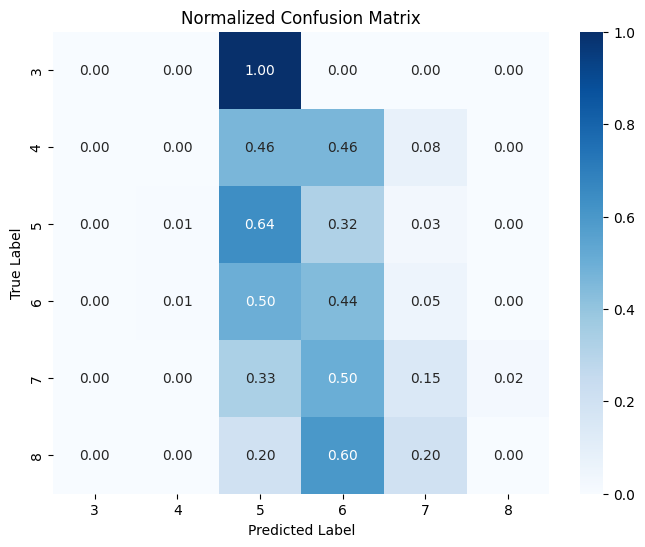


Accuracy Score: 0.4675

Precision, Recall, and F1-score per class:
Class 3:
  Precision: 0.0000
  Recall: 0.0000
  F1-score: 0.0000
Class 4:
  Precision: 0.0000
  Recall: 0.0000
  F1-score: 0.0000
Class 5:
  Precision: 0.4930
  Recall: 0.6402
  F1-score: 0.5570
Class 6:
  Precision: 0.4658
  Recall: 0.4438
  F1-score: 0.4545
Class 7:
  Precision: 0.3043
  Recall: 0.1458
  F1-score: 0.1972
Class 8:
  Precision: 0.0000
  Recall: 0.0000
  F1-score: 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [12]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Calculate Normalized Confusion Matrix
# The rows are the true labels, columns are the predicted labels
normalized_conf_matrix = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]
print("\nNormalized Confusion Matrix:")
print(normalized_conf_matrix)

# Visualize Normalized Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(normalized_conf_matrix, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=sorted(y_test.unique()), yticklabels=sorted(y_test.unique()))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Normalized Confusion Matrix')
plt.show()

# Calculate Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy Score: {accuracy:.4f}")

# Calculate Precision, Recall, and F1-score for each class
# The 'labels' parameter ensures that all classes are reported, even if not present in y_pred
precision, recall, f1_score, _ = precision_recall_fscore_support(y_test, y_pred, average=None, labels=sorted(wine_df['quality'].unique()))

print("\nPrecision, Recall, and F1-score per class:")
for i, class_id in enumerate(sorted(wine_df['quality'].unique())):
    print(f"Class {class_id}:\n  Precision: {precision[i]:.4f}\n  Recall: {recall[i]:.4f}\n  F1-score: {f1_score[i]:.4f}")

# Challenge 4

The code below loads the same dataset, but treats it as a binary classification problem. That is, instead of classifying an observation into one of 10 categories (0..10), we consider all observations with score above 5 as being good and all observation below or equal to five as being bad.





In [13]:
# Code to load the data from file. Here we use the pandas library to read the csv file.
datafile = "./sample_data/problem_set02/wineQualityReds.csv"
wine_df = pd.read_csv(datafile)
wine_df.drop(wine_df.columns[0],axis=1,inplace=True)

wine_df['quality'] = np.where(wine_df['quality']>5,"Good","Bad")

In [14]:
X_train, X_test, y_train, y_test = train_test_split(wine_df.drop('quality',axis=1), wine_df['quality'], test_size=.25, random_state=42)


## Callenge 4.1
Use the variables `X_train`, `X_test`, `y_train`, and `y_test` to explore your data. In particular, calculate and display the following information.
* Number of samples in the training set in total and in each class.
* Number of samples in the testing set in total and in each class.
* Number of features in the dataset.
* Number of classes in the dataset.
* IDs of the number of classes.




In [15]:
# Number of samples in the training set in total and in each class.
print(f"Total samples in training set: {len(X_train)}")
print("Samples per class in training set:")
print(y_train.value_counts().sort_index())

# Number of samples in the testing set in total and in each class.
print(f"\nTotal samples in testing set: {len(X_test)}")
print("Samples per class in testing set:")
print(y_test.value_counts().sort_index())

# Number of features in the dataset.
print(f"\nNumber of features in the dataset: {X_train.shape[1]}")

# Number of classes in the dataset.
num_classes = len(wine_df['quality'].unique())
print(f"Number of classes in the dataset: {num_classes}")

# IDs of the number of classes.
class_ids = sorted(wine_df['quality'].unique())
print(f"IDs of the classes: {class_ids}")

Total samples in training set: 1199
Samples per class in training set:
quality
Bad     566
Good    633
Name: count, dtype: int64

Total samples in testing set: 400
Samples per class in testing set:
quality
Bad     178
Good    222
Name: count, dtype: int64

Number of features in the dataset: 11
Number of classes in the dataset: 2
IDs of the classes: ['Bad', 'Good']


## Challenge 4.2
Train a **K-NN** classifier using the `(X_train,y_train)` dataset and use trained model to predict the underlying classes for the observations in the test dataset `X_test`. Store your prediction in a variable called `y_pred`.

In [16]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize the K-NN classifier (using default 5 neighbors as before)
knn_classifier_binary = KNeighborsClassifier(n_neighbors=5)

# Train the classifier using the training data
knn_classifier_binary.fit(X_train, y_train)

# Predict the classes for the test dataset
y_pred = knn_classifier_binary.predict(X_test)

print("K-NN Classifier for binary classification trained and predictions made. Predictions stored in 'y_pred'.")

K-NN Classifier for binary classification trained and predictions made. Predictions stored in 'y_pred'.


## Challenge 4.3
Evaluate the performance of your classifier. Calculate and display the following:
* print the `confusion matrix`.
* `normalized confusion matrix`.
* the probablitity of correct classification (accuracy score).
* the `precision`, `recall`, and `f1-score` for each class.

Confusion Matrix (Binary Classification):
[[104  74]
 [ 78 144]]

Normalized Confusion Matrix (Binary Classification):
[[0.58426966 0.41573034]
 [0.35135135 0.64864865]]


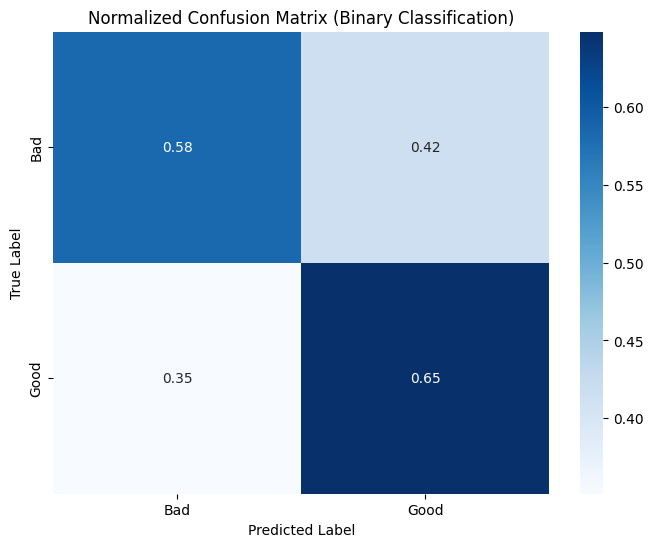


Accuracy Score (Binary Classification): 0.6200

Precision, Recall, and F1-score per class (Binary Classification):
Class Bad:
  Precision: 0.5714
  Recall: 0.5843
  F1-score: 0.5778
Class Good:
  Precision: 0.6606
  Recall: 0.6486
  F1-score: 0.6545


In [19]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate Confusion Matrix
conf_matrix_binary = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (Binary Classification):")
print(conf_matrix_binary)

# Calculate Normalized Confusion Matrix
# The rows are the true labels, columns are the predicted labels
normalized_conf_matrix_binary = conf_matrix_binary.astype('float') / conf_matrix_binary.sum(axis=1)[:, np.newaxis]
print("\nNormalized Confusion Matrix (Binary Classification):")
print(normalized_conf_matrix_binary)

# Visualize Normalized Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(normalized_conf_matrix_binary, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=sorted(y_test.unique()), yticklabels=sorted(y_test.unique()))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Normalized Confusion Matrix (Binary Classification)')
plt.show()

# Calculate Accuracy Score
accuracy_binary = accuracy_score(y_test, y_pred)
print(f"\nAccuracy Score (Binary Classification): {accuracy_binary:.4f}")

# Calculate Precision, Recall, and F1-score for each class
# The 'labels' parameter ensures that all classes are reported, even if not present in y_pred
precision_binary, recall_binary, f1_score_binary, _ = precision_recall_fscore_support(y_test, y_pred, average=None, labels=sorted(wine_df['quality'].unique()))

print("\nPrecision, Recall, and F1-score per class (Binary Classification):")
for i, class_id in enumerate(sorted(wine_df['quality'].unique())):
    print(f"Class {class_id}:\n  Precision: {precision_binary[i]:.4f}\n  Recall: {recall_binary[i]:.4f}\n  F1-score: {f1_score_binary[i]:.4f}")

# Challenge 5

The **Knn** classifier accepts a number of parameters. One of those parameters is the number K (i.e. the number of nearest neighbors to consider when making a prediction. Evaluate the classifier for different values of K and identify which configuration achieve the best performance on the testing set. Plot or print your results.


Defined K values for evaluation: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30]
Defined K values for evaluation: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30]
Accuracies for different K values calculated.
Accuracies for different K values calculated.
Best K value: 1
Highest accuracy: 0.6475


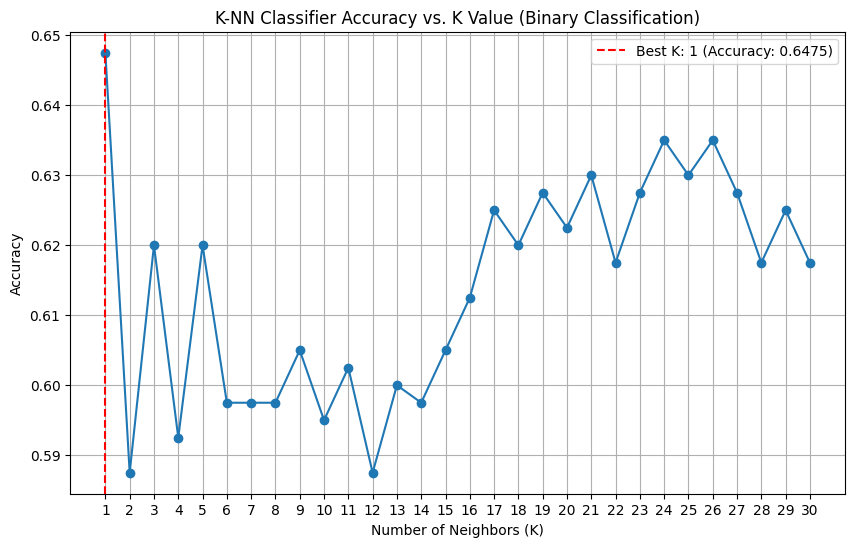

Accuracy vs. K value plot displayed.


In [31]:
# Your solution here.
k_values = np.arange(1, 31) # Create an array of integers from 1 to 30
print(f"Defined K values for evaluation: {k_values}")
k_values = np.arange(1, 31) # Create an array of integers from 1 to 30
print(f"Defined K values for evaluation: {k_values}")
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

accuracies = []

for k in k_values:
    # Initialize the K-NN classifier with the current k value
    knn_classifier_k = KNeighborsClassifier(n_neighbors=k)

    # Train the classifier using the training data (binary classification setup)
    knn_classifier_k.fit(X_train, y_train)

    # Predict the classes for the test dataset
    y_pred_k = knn_classifier_k.predict(X_test)

    # Calculate the accuracy score for the current k
    accuracy_k = accuracy_score(y_test, y_pred_k)
    accuracies.append(accuracy_k)

print("Accuracies for different K values calculated.")
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

accuracies = []

for k in k_values:
    # Initialize the K-NN classifier with the current k value
    knn_classifier_k = KNeighborsClassifier(n_neighbors=k)

    # Train the classifier using the training data (binary classification setup)
    knn_classifier_k.fit(X_train, y_train)

    # Predict the classes for the test dataset
    y_pred_k = knn_classifier_k.predict(X_test)

    # Calculate the accuracy score for the current k
    accuracy_k = accuracy_score(y_test, y_pred_k)
    accuracies.append(accuracy_k)

print("Accuracies for different K values calculated.")
max_accuracy_index = np.argmax(accuracies)
best_k = k_values[max_accuracy_index]
best_accuracy = accuracies[max_accuracy_index]

print(f"Best K value: {best_k}")
print(f"Highest accuracy: {best_accuracy:.4f}")
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='-')
plt.title('K-NN Classifier Accuracy vs. K Value (Binary Classification)')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.xticks(k_values) # Ensure all K values are shown on the x-axis
plt.grid(True)

# Highlight the best K value
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Best K: {best_k} (Accuracy: {best_accuracy:.4f})')
plt.legend()
plt.show()

print("Accuracy vs. K value plot displayed.")


Copyright Statement: Copyright © 2020 Christoforou. The materials provided by the instructor of this course, including this notebook, are for the use of the students enrolled in the course. Materials are presented in an educational context for personal use and study and should not be shared, distributed, disseminated or sold in print — or digitally — outside the course without permission. You may not, nor may you knowingly allow others to reproduce or distribute lecture notes, course materials as well as any of their derivatives without the instructor's express written consent.